In [293]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
# train VAE to learn the dynamic of inventory control problem
# s: inventory level, a: order quantity, r: reward, o: demand
# N = 10, k = 1, c = 2, z = 2, p = 4, lambda = 5.
# 0 \le a \le N
# o ~ Poisson(lambda)
# s' = max(0, min(N, s + a) - o)
# r = -k * 1(a>0) - c * (min(N, s + a) - s) - z * s + p * min(o, s+a)

class Inventory_Simulator(object):
    def __init__(self, N, k, c, z, p, lambda_, H):
        self.N = N
        self.k = k
        self.c = c
        self.z = z
        self.p = p
        self.lambda_ = lambda_
        self.H = H

    def reset(self): # return the initial state
        return np.random.uniform(0, self.N, (1,))

    def step(self, s, a, h): # transition function
        o = np.random.normal(5, 1, (1,)) # demand
        s1 = np.clip(np.clip(s + a, a_min=None, a_max=self.N) - o, 0, None)
        # s1 = np.array(s1)
        r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
        r = float(r)
        done = (h == self.H - 1)
        return s, a, r, s1, done


class Noisy_Inventory_Simulator(object):
    def __init__(self, N, k, c, z, p, lambda_, H):
        self.N = N
        self.k = k
        self.c = c
        self.z = z
        self.p = p
        self.lambda_ = lambda_
        self.H = H

    def reset(self): # return the initial state
        return np.random.uniform(0, self.N, (1,))

    def step(self, s, a, h): # transition function
        o = np.random.normal(5, 1, (1,)) # demand
        s1 = np.clip(np.clip(s + a + np.random.normal(0, 1, (1,)), a_min=None, a_max=self.N) - o, 0, None)
        r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a) + np.random.normal(1, 1, (1,)) # some positive bias
        r = float(r)
        done = (h == self.H - 1)
        return s, a, r, s1, done

In [294]:
env = Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=20)
noisy_env = Noisy_Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=20)

In [295]:
# define 10 policies to evaluate
# several [a, b] uniform policies
# several (s, S) policies
# several N(mu, sigma^2) policies
from scipy.stats import norm

class uniform_policy(object):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def act(self, s):
        a = np.random.randint(self.a, self.b+1, (1,))
        return a
    
    def prob(self, s, a):
        return 1.0 / (self.b - self.a + 1)

class sS_policy(object):
    def __init__(self, s, S):
        self.a = s
        self.b = S

    def act(self, s):
        if s < self.a:
            a = self.b - s
        else:
            a = np.random.uniform(0, 0, (1,))
        return a

class normal_policy(object):
    def __init__(self, mu, sigma):
        self.mu = mu
        self.sigma = sigma

    def act(self, s):
        # sample from 0 to 10, with the probability proportional to exp(-|x-mu+s|)
        prob = [float(np.exp(-abs(x - self.mu + s))) for x in range(11)]
        # normalize the probability
        prob = [p/sum(prob) for p in prob]
        a = np.random.choice(range(11), p=prob)
        return a
    
    def prob(self, s, a):
        # calculate the probability of a given s and a
        prob = [float(np.exp(-abs(x - self.mu + s))) for x in range(11)]
        # normalize the probability
        prob = [p/sum(prob) for p in prob]
        return prob[int(a)]
        # prob = 1.0 / (self.sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((a - self.mu + s) / self.sigma) ** 2)
        # # reweight for truncated normal distribution
        # # compute P(0 <= X <= 10)
        # integral_0_10 = norm.cdf(10, loc=self.mu-s, scale=self.sigma) - norm.cdf(0, loc = self.mu-s, scale=self.sigma)
        # return prob / integral_0_10

class approximate_uniform_policy(object):
    def __init__(self, a, b, eps):
        self.a = a
        self.b = b
        self.eps = eps
        self.idx_add_eps = range(5)
        self.idx_sub_eps = range(5, 10)
        self.prob_list = [1/11 for _ in range(11)]
        for i in self.idx_add_eps:
            self.prob_list[i] = self.prob_list[i] + self.eps
        for i in self.idx_sub_eps:
            self.prob_list[i] = self.prob_list[i] - self.eps

    def act(self, s):
        a = np.random.choice(range(11), p=self.prob_list)
        return a
    
    def prob(self, s, a):
        return self.prob_list[int(a)]


In [301]:
pi_u_0_10 = uniform_policy(0, 10)
pi_u_0_5 = uniform_policy(0, 5)
pi_u_3_8 = uniform_policy(3, 8)
pi_u_0_0 = uniform_policy(0, 0)
pi_u_6_6 = uniform_policy(6, 6)

pi_sS_3_10 = sS_policy(3, 10)
pi_sS_3_6 = sS_policy(3, 6)
pi_sS_7_10 = sS_policy(7, 10)
pi_sS_1_5 = sS_policy(1, 5)
pi_sS_5_8 = sS_policy(5, 8)

pi_n_10_1 = normal_policy(5.5, 1)

result = pd.DataFrame(columns=['delta', 'iter', 'V_PPI', 'lower_bound', 'upper_bound'])

for delta in np.linspace(0, 0.1, 10, endpoint=False):
    approximate_pi_u_0_10 = approximate_uniform_policy(0, 10, delta)
    pi_b = pi_u_0_10
    pi_e = approximate_pi_u_0_10
    min_ratio = pi_e.prob(0, 5) / pi_b.prob(0, 5)

    gamma = 0.9
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(250):
        s = env.reset()
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_b.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (gamma ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
    # convert to dictionary
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }
    # save as 0_o.pkl
    with open('dr_ci_trajs/train_0_o.pkl', 'wb') as f:
        pickle.dump(data, f)

    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(250):
        s = env.reset()
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_b.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (gamma ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
    # convert to dictionary
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }
    # save as 0_o.pkl
    with open('dr_ci_trajs/first_term_0_o.pkl', 'wb') as f:
        pickle.dump(data, f)


    for iter in range(10):

        train_trajectories = pickle.load(open("dr_ci_trajs/train_0_o.pkl", "rb"))
        _trajectories = []
        _actions_trajectories = []
        _rewards = []
        for i in range(len(train_trajectories['trajectories'])):
            s0 = train_trajectories['trajectories'][i][0]
            for _ in range(100): # M = 100
                s = s0
                reward = 0
                trajectory = []
                action_trajectory = []
                for h in range(env.H):
                    a = pi_e.act(s)
                    s, a, r, s1, done = noisy_env.step(s, a, h)
                    trajectory.append(s)
                    action_trajectory.append(a)
                    reward += r * (gamma ** h)
                    s = s1
                _trajectories.append(trajectory)
                _actions_trajectories.append(action_trajectory)
                _rewards.append(reward)
        # convert to dictionary
        data = {
            'trajectories': np.array(_trajectories),
            'actions': np.array(_actions_trajectories),
            'rewards': np.array(_rewards)
        }
        # save as 0_o.pkl
        with open('dr_ci_trajs/train_9_diff.pkl', 'wb') as f:
            pickle.dump(data, f)
        

        train_trajectories = pickle.load(open("dr_ci_trajs/first_term_0_o.pkl", "rb"))
        _trajectories = []
        _actions_trajectories = []
        _rewards = []
        for i in range(len(train_trajectories['trajectories'])):
            s0 = train_trajectories['trajectories'][i][0]
            for _ in range(100): # N_f = 250*100
                s = s0
                reward = 0
                trajectory = []
                action_trajectory = []
                for h in range(env.H):
                    a = pi_e.act(s)
                    s, a, r, s1, done = noisy_env.step(s, a, h)
                    trajectory.append(s)
                    action_trajectory.append(a)
                    reward += r * (gamma ** h)
                    s = s1
                _trajectories.append(trajectory)
                _actions_trajectories.append(action_trajectory)
                _rewards.append(reward)
        # convert to dictionary
        data = {
            'trajectories': np.array(_trajectories),
            'actions': np.array(_actions_trajectories),
            'rewards': np.array(_rewards)
        }
        with open('dr_ci_trajs/first_term_9_diff.pkl', 'wb') as f:
            pickle.dump(data, f)
        
                
        train_0_o = pickle.load(open("dr_ci_trajs/train_0_o.pkl", "rb"))
        train_9_diff = pickle.load(open("dr_ci_trajs/train_9_diff.pkl", "rb"))
        first_term_diff = pickle.load(open("dr_ci_trajs/first_term_9_diff.pkl", "rb"))

        first_term_diff_rewards = first_term_diff['rewards']
        first_term_diff_rewards = np.array(first_term_diff_rewards)

        sigma_f2 = np.var(first_term_diff_rewards)
        
        pi_b_0_trajs = train_0_o['trajectories']
        pi_b_0_actions = train_0_o['actions']
        pi_b_0_rewards = train_0_o['rewards']
        pi_e_diff_trajs = train_9_diff['trajectories']
        pi_e_diff_actions = train_9_diff['actions']
        pi_e_diff_rewards = train_9_diff['rewards']

        s0_pairs = []
        for i in range(len(pi_b_0_trajs)):
            for j in range(len(pi_e_diff_trajs)):
                if pi_b_0_trajs[i][0] == pi_e_diff_trajs[j][0]:
                    s0_pairs.append((i, j))
        
        weights = np.zeros(len(pi_b_0_trajs))
        for i in range(len(pi_b_0_trajs)):
            w = 1
            for t in range(len(pi_b_0_trajs[i])):
                w *= pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / pi_b.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
            weights[i] = w
        
        E_diff_rewards = np.zeros(len(pi_b_0_trajs))
        for i, j in s0_pairs:  
            diff = weights[i]*pi_b_0_rewards[i] - pi_e_diff_rewards[j]
            E_diff_rewards[i] += diff
        E_diff_rewards = E_diff_rewards / (len(pi_e_diff_trajs)/len(pi_b_0_trajs))

        sigma_b2 = np.var(E_diff_rewards)

        V_PPI = np.mean(first_term_diff_rewards) + np.mean(E_diff_rewards)
        sigma_V2 = sigma_f2/len(first_term_diff_rewards) + sigma_b2/len(E_diff_rewards)
        alpha = 0.1
        # calculate the confidence interval using normal approximation
        z = norm.ppf(1 - alpha/2)
        lower_bound = V_PPI - z * np.sqrt(sigma_V2)
        upper_bound = V_PPI + z * np.sqrt(sigma_V2)

        # save a row to result
        result = pd.concat([result, pd.DataFrame({'delta': [delta], 'iter': [iter], 'V_PPI': [V_PPI], 'lower_bound': [lower_bound], 'upper_bound': [upper_bound]})], ignore_index=True)
        print(f"delta: {delta}, iter: {iter}, V_PPI: {V_PPI}, lower_bound: {lower_bound}, upper_bound: {upper_bound}")

# save the result
result.to_csv('dr_ci_trajs/result.csv', index=False)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/2130543499.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/2130543499.py:32: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/2130543499.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operatio

delta: 0.0, iter: 0, V_PPI: 21.558605142240836, lower_bound: 20.229869771566456, upper_bound: 22.887340512915216
delta: 0.0, iter: 1, V_PPI: 21.67223331846521, lower_bound: 20.347658335792477, upper_bound: 22.996808301137943
delta: 0.0, iter: 2, V_PPI: 21.530633653826584, lower_bound: 20.213269737927195, upper_bound: 22.847997569725973
delta: 0.0, iter: 3, V_PPI: 21.7522092009408, lower_bound: 20.430492379877457, upper_bound: 23.073926022004144
delta: 0.0, iter: 4, V_PPI: 21.720348699307717, lower_bound: 20.386275405978694, upper_bound: 23.05442199263674
delta: 0.0, iter: 5, V_PPI: 21.76710223567285, lower_bound: 20.455069585926207, upper_bound: 23.079134885419496
delta: 0.0, iter: 6, V_PPI: 21.7450220342348, lower_bound: 20.416192409191837, upper_bound: 23.073851659277764
delta: 0.0, iter: 7, V_PPI: 21.661881956859563, lower_bound: 20.337072157293527, upper_bound: 22.9866917564256
delta: 0.0, iter: 8, V_PPI: 21.507109605532314, lower_bound: 20.17190177763533, upper_bound: 22.842317433

In [302]:
result

,delta,iter,V_PPI,lower_bound,upper_bound
0,0.00,0,21.558605,20.229870,22.887341
1,0.00,1,21.672233,20.347658,22.996808
2,0.00,2,21.530634,20.213270,22.847998
3,0.00,3,21.752209,20.430492,23.073926
4,0.00,4,21.720349,20.386275,23.054422
...,...,...,...,...,...
95,0.09,5,-0.100921,-0.308257,0.106414
96,0.09,6,0.144168,-0.060205,0.348542
97,0.09,7,0.069348,-0.135004,0.273700
98,0.09,8,0.092450,-0.112353,0.297252


In [272]:
# generate 500 trajectories from pi_u_0_10, saved as training dataset
gamma = 0.9
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(250):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('dr_ci_trajs/train_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)


In [273]:
# generate trajectories from pi_n_10_1, conditioned on the initial state of each traj in 0_o.pkl
train_trajectories = pickle.load(open("dr_ci_trajs/train_0_o.pkl", "rb"))
_trajectories = []
_actions_trajectories = []
_rewards = []
for i in range(len(train_trajectories['trajectories'])):
    s0 = train_trajectories['trajectories'][i][0]
    for _ in range(100): # M = 100
        s = s0
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_e.act(s)
            s, a, r, s1, done = noisy_env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (gamma ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('dr_ci_trajs/train_9_diff.pkl', 'wb') as f:
    pickle.dump(data, f)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)


In [274]:
# generate 500 trajectories from pi_u_0_10, saved as training dataset
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(500):
    s = env.reset()
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_b.act(s)
        s, a, r, s1, done = env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
# save as 0_o.pkl
with open('dr_ci_trajs/first_term_0_o.pkl', 'wb') as f:
    pickle.dump(data, f)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)


In [275]:
# generate trajectories from pi_n_10_1, conditioned on the initial state of each traj in 0_o.pkl
train_trajectories = pickle.load(open("dr_ci_trajs/first_term_0_o.pkl", "rb"))
_trajectories = []
_actions_trajectories = []
_rewards = []
for i in range(len(train_trajectories['trajectories'])):
    s0 = train_trajectories['trajectories'][i][0]
    for _ in range(100): # N_f = 500*100
        s = s0
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_e.act(s)
            s, a, r, s1, done = noisy_env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (gamma ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
# convert to dictionary
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}
with open('dr_ci_trajs/first_term_9_diff.pkl', 'wb') as f:
    pickle.dump(data, f)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)


In [276]:
# calculate the variance of 
# first_term_9_diff = \sigma_f^2
# train_0_o - train_9_diff = \sigma_b^2
train_0_o = pickle.load(open("dr_ci_trajs/train_0_o.pkl", "rb"))
train_9_diff = pickle.load(open("dr_ci_trajs/train_9_diff.pkl", "rb"))
first_term_diff = pickle.load(open("dr_ci_trajs/first_term_9_diff.pkl", "rb"))

first_term_diff_rewards = first_term_diff['rewards']
first_term_diff_rewards = np.array(first_term_diff_rewards)

sigma_f2 = np.var(first_term_diff_rewards)

In [277]:
pi_b_0_trajs = train_0_o['trajectories']
pi_b_0_actions = train_0_o['actions']
pi_b_0_rewards = train_0_o['rewards']
pi_e_diff_trajs = train_9_diff['trajectories']
pi_e_diff_actions = train_9_diff['actions']
pi_e_diff_rewards = train_9_diff['rewards']

s0_pairs = []
for i in range(len(pi_b_0_trajs)):
    for j in range(len(pi_e_diff_trajs)):
        if pi_b_0_trajs[i][0] == pi_e_diff_trajs[j][0]:
            s0_pairs.append((i, j))
print(len(s0_pairs))

50000


In [278]:
weights = np.zeros(len(pi_b_0_trajs))
for i in range(len(pi_b_0_trajs)):
    w = 1
    for t in range(len(pi_b_0_trajs[i])):
        w *= pi_e.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / pi_b.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
    weights[i] = w
# # normalize the weights
# weights = weights / np.sum(weights)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3697446143.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return self.prob_list[int(a)]


(array([494.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([1.56823920e-31, 6.04852141e-06, 1.20970428e-05, 1.81455642e-05,
        2.41940857e-05, 3.02426071e-05, 3.62911285e-05, 4.23396499e-05,
        4.83881713e-05, 5.44366927e-05, 6.04852141e-05, 6.65337356e-05,
        7.25822570e-05, 7.86307784e-05, 8.46792998e-05, 9.07278212e-05,
        9.67763426e-05, 1.0282

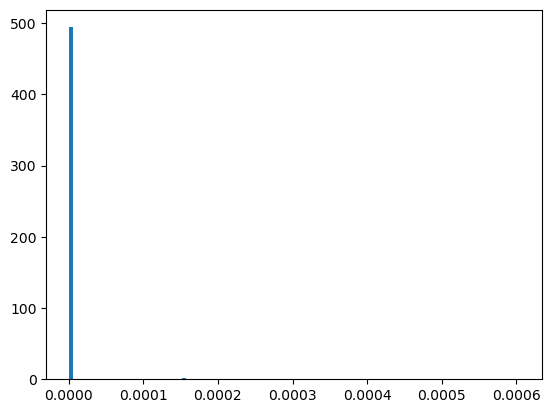

In [279]:
# plot the distribution of weights
plt.hist(weights, bins=100)

In [280]:
# for each traj in pi_b_0_trajs, calculate the mean reward difference
E_diff_rewards = np.zeros(len(pi_b_0_trajs))
for i, j in s0_pairs:  
    diff = weights[i]*pi_b_0_rewards[i] - pi_e_diff_rewards[j]
    E_diff_rewards[i] += diff
E_diff_rewards = E_diff_rewards / (len(pi_e_diff_trajs)/len(pi_b_0_trajs))

In [281]:
sigma_b2 = np.var(E_diff_rewards)

In [282]:
len(first_term_diff_rewards), len(E_diff_rewards), sigma_b2, sigma_f2

(50000, 500, 3.4014221566503307, 64.76520959038817)

In [283]:
np.mean(first_term_diff_rewards), np.mean(E_diff_rewards)

(37.61177540644402, -37.54036486946279)

In [284]:
V_PPI = np.mean(first_term_diff_rewards) + np.mean(E_diff_rewards)
sigma_V2 = sigma_f2/len(first_term_diff_rewards) + sigma_b2/len(E_diff_rewards)
alpha = 0.05
# calculate the confidence interval using normal approximation
z = norm.ppf(1 - alpha/2)
lower_bound = V_PPI - z * np.sqrt(sigma_V2)
upper_bound = V_PPI + z * np.sqrt(sigma_V2)
print("V_PPI: ", V_PPI)
print("lower bound: ", lower_bound)
print("upper bound: ", upper_bound)


V_PPI:  0.0714105369812259
lower bound:  -0.10496606012349122
upper bound:  0.24778713408594302


In [263]:
# evaluate the policies by MC for 10000 episodes
def evaluate_policy(env, policy, gamma, num_episodes=1000):
    total_reward = 0
    for _ in range(num_episodes):
        s = env.reset()
        for h in range(env.H):
            a = policy.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            total_reward += r * (gamma ** h)
            s = s1
    return total_reward / num_episodes


evaluate_policy(env, pi_e, gamma=0.9, num_episodes=10000)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)


28.55285423458171

In [139]:
V_PPI_list = []
V_up_list = []
V_low_list = []
V_true_list = []

In [140]:
for h1 in range(2, 8):
    env = Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=h1)
    noisy_env = Noisy_Inventory_Simulator(N=10, k=1, c=2, z=2, p=4, lambda_=5, H=h1)
    
    # generate 500 trajectories from pi_u_0_10, saved as training dataset
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(500):
        s = env.reset()
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_u_0_10.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (0.9 ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
    # convert to dictionary
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }
    # save as 0_o.pkl
    with open('dr_ci_trajs/train_0_o.pkl', 'wb') as f:
        pickle.dump(data, f)

    # generate trajectories from pi_n_10_1, conditioned on the initial state of each traj in 0_o.pkl
    train_trajectories = pickle.load(open("dr_ci_trajs/train_0_o.pkl", "rb"))
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for i in range(len(train_trajectories['trajectories'])):
        s0 = train_trajectories['trajectories'][i][0]
        for _ in range(1000): # M = 1000
            s = s0
            reward = 0
            trajectory = []
            action_trajectory = []
            for h in range(env.H):
                a = pi_n_10_1.act(s)
                s, a, r, s1, done = noisy_env.step(s, a, h)
                trajectory.append(s)
                action_trajectory.append(a)
                reward += r * (0.9 ** h)
                s = s1
            _trajectories.append(trajectory)
            _actions_trajectories.append(action_trajectory)
            _rewards.append(reward)
    # convert to dictionary
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }
    # save as 0_o.pkl
    with open('dr_ci_trajs/train_9_diff.pkl', 'wb') as f:
        pickle.dump(data, f)

    # generate 500 trajectories from pi_u_0_10, saved as training dataset
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for _ in range(500):
        s = env.reset()
        reward = 0
        trajectory = []
        action_trajectory = []
        for h in range(env.H):
            a = pi_u_0_10.act(s)
            s, a, r, s1, done = env.step(s, a, h)
            trajectory.append(s)
            action_trajectory.append(a)
            reward += r * (0.9 ** h)
            s = s1
        _trajectories.append(trajectory)
        _actions_trajectories.append(action_trajectory)
        _rewards.append(reward)
    # convert to dictionary
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }
    # save as 0_o.pkl
    with open('dr_ci_trajs/first_term_0_o.pkl', 'wb') as f:
        pickle.dump(data, f)

    # generate trajectories from pi_n_10_1, conditioned on the initial state of each traj in 0_o.pkl
    train_trajectories = pickle.load(open("dr_ci_trajs/first_term_0_o.pkl", "rb"))
    _trajectories = []
    _actions_trajectories = []
    _rewards = []
    for i in range(len(train_trajectories['trajectories'])):
        s0 = train_trajectories['trajectories'][i][0]
        for _ in range(100): # N_f = 500*100
            s = s0
            reward = 0
            trajectory = []
            action_trajectory = []
            for h in range(env.H):
                a = pi_n_10_1.act(s)
                s, a, r, s1, done = noisy_env.step(s, a, h)
                trajectory.append(s)
                action_trajectory.append(a)
                reward += r * (0.9 ** h)
                s = s1
            _trajectories.append(trajectory)
            _actions_trajectories.append(action_trajectory)
            _rewards.append(reward)
    # convert to dictionary
    data = {
        'trajectories': np.array(_trajectories),
        'actions': np.array(_actions_trajectories),
        'rewards': np.array(_rewards)
    }
    with open('dr_ci_trajs/first_term_9_diff.pkl', 'wb') as f:
        pickle.dump(data, f)

    # calculate the variance of 
    # first_term_9_diff = \sigma_f^2
    # train_0_o - train_9_diff = \sigma_b^2
    train_0_o = pickle.load(open("dr_ci_trajs/train_0_o.pkl", "rb"))
    train_9_diff = pickle.load(open("dr_ci_trajs/train_9_diff.pkl", "rb"))
    first_term_diff = pickle.load(open("dr_ci_trajs/first_term_9_diff.pkl", "rb"))

    first_term_diff_rewards = first_term_diff['rewards']
    first_term_diff_rewards = np.array(first_term_diff_rewards)

    sigma_f2 = np.var(first_term_diff_rewards)

    pi_b_0_trajs = train_0_o['trajectories']
    pi_b_0_actions = train_0_o['actions']
    pi_b_0_rewards = train_0_o['rewards']
    pi_e_diff_trajs = train_9_diff['trajectories']
    pi_e_diff_actions = train_9_diff['actions']
    pi_e_diff_rewards = train_9_diff['rewards']

    s0_pairs = []
    for i in range(len(pi_b_0_trajs)):
        for j in range(len(pi_e_diff_trajs)):
            if pi_b_0_trajs[i][0] == pi_e_diff_trajs[j][0]:
                s0_pairs.append((i, j))

    weights = np.zeros(len(pi_b_0_trajs))
    for i in range(len(pi_b_0_trajs)):
        w = 1
        for t in range(len(pi_b_0_trajs[i])):
            w *= pi_n_10_1.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t]) / pi_u_0_10.prob(pi_b_0_trajs[i][t], pi_b_0_actions[i][t])
        weights[i] = w

    # for each traj in pi_b_0_trajs, calculate the mean reward difference
    E_diff_rewards = np.zeros(len(pi_b_0_trajs))
    for i, j in s0_pairs:  
        diff = weights[i]*pi_b_0_rewards[i] - pi_e_diff_rewards[j]
        E_diff_rewards[i] += diff
    E_diff_rewards = E_diff_rewards / (len(pi_e_diff_trajs)/len(pi_b_0_trajs))

    sigma_b2 = np.var(E_diff_rewards)

    V_PPI = np.mean(first_term_diff_rewards) + np.mean(E_diff_rewards)
    sigma_V2 = sigma_f2/len(first_term_diff_rewards) + sigma_b2/len(E_diff_rewards)
    alpha = 0.01
    # calculate the confidence interval using normal approximation
    z = norm.ppf(1 - alpha/2)
    lower_bound = V_PPI - z * np.sqrt(sigma_V2)
    upper_bound = V_PPI + z * np.sqrt(sigma_V2)
    V_PPI_list.append(V_PPI)
    V_up_list.append(upper_bound)
    V_low_list.append(lower_bound)

    V_true = evaluate_policy(env, pi_n_10_1, gamma=0.9, num_episodes=10000)
    V_true_list.append(V_true)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = -self.k * int(a > 0) - self.c * (min(self.N, s + a) - s) - self.z * s + self.p * min(o, s + a)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3275939446.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operatio

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/4164785724.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$V^{\pi_e}$')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, '$V^{\\pi_e}$')

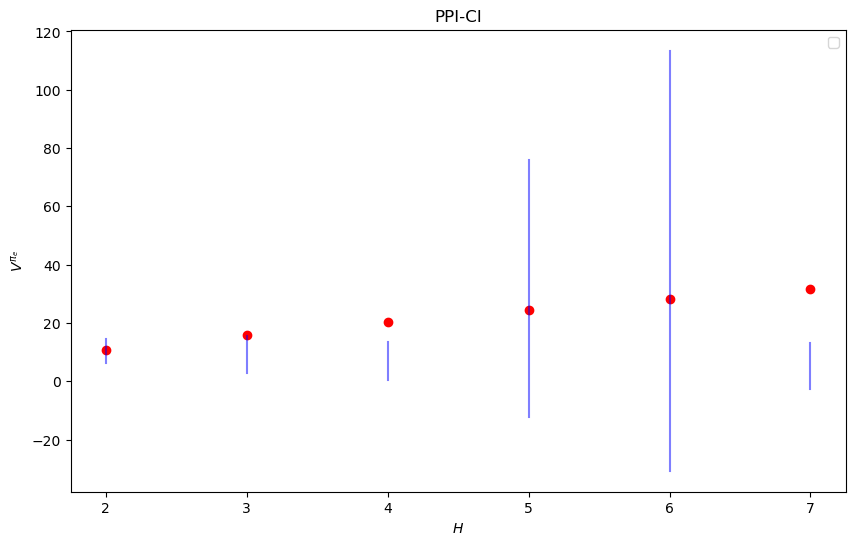

In [141]:
# plot the CP and values
# x-axis: start_s
# y-axis: dot is the value of policy, the interval is the CP
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(range(2, 8), V_true_list, color='red')
for i in range(2, 8):
    plt.plot([i, i], [V_low_list[i-2], V_up_list[i-2]], color='blue', alpha=0.5)
plt.title('PPI-CI')
plt.legend()
# y-axis range (0, 100)
# plt.ylim(-10, 100)
plt.xlabel('$H$')
plt.ylabel('$V^{\pi_e}$')


In [265]:
len(s0_pairs)

50000

In [285]:
# build a per-state version of the PPI

start_s = 8
eps_s = 0.3

s0_pairs_s = []
for i, j in s0_pairs:
    if pi_b_0_trajs[i][0] > start_s - eps_s and pi_b_0_trajs[i][0] < start_s + eps_s:
        s0_pairs_s.append((i, j))
print(len(s0_pairs_s))


2500


In [286]:
# for each traj in pi_b_0_trajs, calculate the mean reward difference
E_diff_rewards_s = []
has_visited = []
for i, j in s0_pairs_s:
    if i not in has_visited:
        diff = weights[i]*pi_b_0_rewards[i] - pi_e_diff_rewards[j]
        E_diff_rewards_s.append(diff)
        has_visited.append(i)
E_diff_rewards_s = np.array(E_diff_rewards_s)
sigma_b2_s = np.var(E_diff_rewards_s)

In [287]:
# generate 500 trajectories from pi_n_10_1, saved as first_term
_trajectories = []
_actions_trajectories = []
_rewards = []
for _ in range(500):
    s = np.array(start_s).reshape(1,)
    reward = 0
    trajectory = []
    action_trajectory = []
    for h in range(env.H):
        a = pi_e.act(s)
        s, a, r, s1, done = noisy_env.step(s, a, h)
        trajectory.append(s)
        action_trajectory.append(a)
        reward += r * (gamma ** h)
        s = s1
    _trajectories.append(trajectory)
    _actions_trajectories.append(action_trajectory)
    _rewards.append(reward)

# convert to dictionary
import pickle
data = {
    'trajectories': np.array(_trajectories),
    'actions': np.array(_actions_trajectories),
    'rewards': np.array(_rewards)
}

# save as 9_first_term.pkl
with open('dr_ci_trajs/9_first_term_s.pkl', 'wb') as f:
    pickle.dump(data, f)

pi_e_diff = pickle.load(open("dr_ci_trajs/9_first_term_s.pkl", "rb"))

pi_e_diff_trajs = pi_e_diff['trajectories']
pi_e_diff_actions = pi_e_diff['actions']
pi_e_diff_rewards = pi_e_diff['rewards']

first_term_diff_rewards_s = np.array(pi_e_diff_rewards)

sigma_f2_s = np.var(first_term_diff_rewards_s)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_83387/3881640425.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = float(r)


In [289]:
np.mean(first_term_diff_rewards_s), np.mean(E_diff_rewards_s)

(36.393001363420176, -36.71963634251934)

In [288]:
V_PPI_s = np.mean(first_term_diff_rewards_s) + np.mean(E_diff_rewards_s)
sigma_V2_s = sigma_f2_s/len(first_term_diff_rewards_s) + sigma_b2/len(E_diff_rewards_s)
alpha = 0.05
# calculate the confidence interval using normal approximation
z = norm.ppf(1 - alpha/2)
lower_bound_s = V_PPI_s - z * np.sqrt(sigma_V2_s)
upper_bound_s = V_PPI_s + z * np.sqrt(sigma_V2_s)
print("V_PPI: ", V_PPI_s)
print("lower bound: ", lower_bound_s)
print("upper bound: ", upper_bound_s)

V_PPI:  -0.32663497909916117
lower bound:  -1.3403730342208742
upper bound:  0.6871030760225518
